# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is linear when it is linear in its parameters, not necessarily in its features. Th equation never has exponents or products of parameters, only multiplication by a constant and addition.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

You interpret the coefficient for a dummy variable as the difference in the predicted value of the dependent variable between the group that the dummy variable represents and the reference group (the group that the dummy variable does not represent).


3. Can linear regression be used for classification? Explain why, or why not.

It can not be used becuase the output of linear regression is not bounded between 0 and 1, which is required for classification.

4. What are signs that your linear model is over-fitting?

The biggest sign of an overfit linear model is that it performs exceptionally well on the data it was trained on (having very low error), but performs poorly when evaluated on new, unseen testing data. This indicates the model has "memorized" the random noise in the training set rather than learning the actual underlying pattern.


5. Clearly explain multi-colinearity using the two-stage least squares technique.

If measuring the effect of an input involves first finding its unique variation apart from other inputs (Stage 1), multicollinearity means it has almost zero unique variation. Regressing the target against that near-zero leftover variation (Stage 2) yields a wildly unstable, unreliable coefficient

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

By transforming your input features X before feeding them to the model. You can add polynomial features x^2, x^3, logarithmic transformations log(x), or interaction terms (x1 * x2). The model remains linear in its parameters but fits a curved line to the data.



7. What is the interpretation of the slope coefficient in a linear regression?

It represents the expected change in the target variable ($y$) for every one-unit increase in that specific feature, assuming all other features are held constant.

8. Compare the train/test split and $k$-fold cross validation.

A simple train/test split divides the data once; it is fast but the evaluation score can vary wildly depending on what data randomly ended up in the test set. k-fold cross-validation splits the data k times, tests on every single fold exactly once, and averages the scores, providing a much more robust and reliable evaluation at the cost of more computation time.

9. How is the $k$ in $k$-fold cross validation typically selected?

k is typically chosen to be 5 or 10. These specific values have been empirically proven to provide the best balance (the bias-variance tradeoff) between computational speed and an accurate estimate of model performance.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.


Average Prices and Scores by Neighbourhood:
                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750




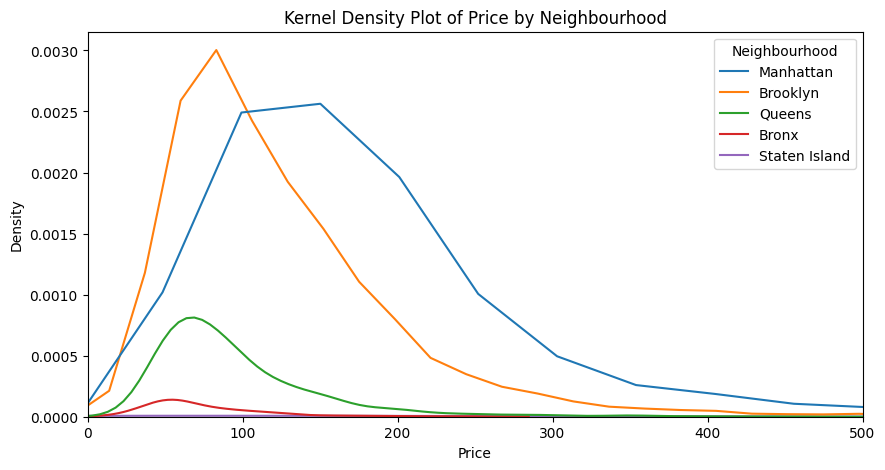

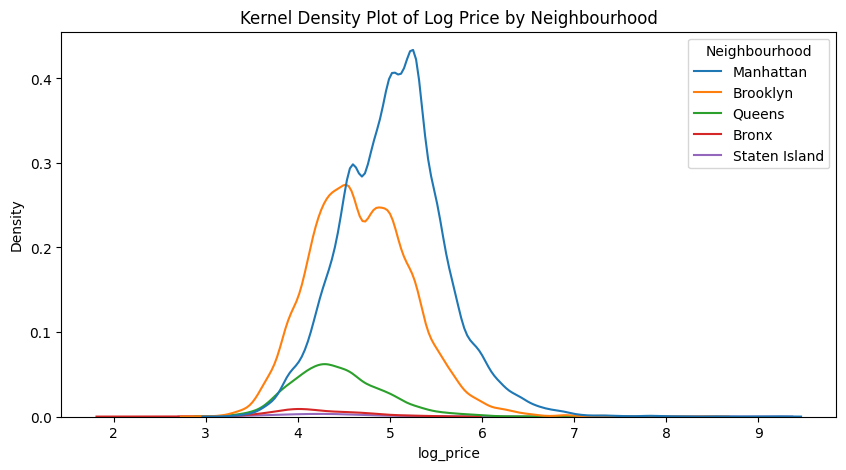

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('./data/Q1_clean.csv')

df = df.rename(columns={'Neighbourhood ': 'Neighbourhood'})

averages = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean()
print("Average Prices and Scores by Neighbourhood:")
print(averages)
print("\n") 

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Price', hue='Neighbourhood')
plt.title('Kernel Density Plot of Price by Neighbourhood')
plt.xlim(0, 500)  
plt.show()

df['log_price'] = np.log(df['Price'])

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='log_price', hue='Neighbourhood')
plt.title('Kernel Density Plot of Log Price by Neighbourhood')
plt.show()



2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?



In [2]:
import statsmodels.api as sm

X_score = df['Review Scores Rating']
Y = df['Price']

X_score = sm.add_constant(X_score)

model_score = sm.OLS(Y, X_score).fit()

print(model_score.summary())



                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        22:43:41   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 



3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.



In [3]:
import statsmodels.api as sm

X_score = df['Review Scores Rating']
Y = df['Price']

X_score = sm.add_constant(X_score)
model_score = sm.OLS(Y, X_score).fit()

print(model_score.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        22:43:41   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

Answer: The slope coefficient for the Review Scores Rating represents the expected average change in the price of a rental (in dollars) for every one-unit increase in the review score rating, assuming all other factors are held constant.


4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?



In [4]:
import statsmodels.api as sm

features = [col for col in df_dummies.columns if col.startswith('Neighbourhood_')]
features.append('Review Scores Rating')

X_both = df_dummies[features]
X_both = X_both.astype(float) 

Y = df['Price']
X_both = sm.add_constant(X_both)
model_both = sm.OLS(Y, X_both, missing='drop').fit()

print(model_both.summary())


NameError: name 'df_dummies' is not defined

It increased slightly from 1.02 to 1.08. By controlling for the neighborhood, I established the true effect of positive reviews on price within a specific geographic location (avoiding being skewed by differences in neighborhood-wide averages).

How the neighborhood averages change: The apparent price differences between neighborhoods shifted slightly (e.g., Manhattan shifted from a $108.39 premium to a $108.23 premium). This shows that a small fraction of the price difference previously attributed purely to "being in Manhattan" was actually due to Manhattan having different average review scores than the Bronx baseline.



5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?



In [ ]:
import statsmodels.api as sm
import pandas as pd

df_dummies_all = pd.get_dummies(df, columns=['Neighbourhood'], drop_first=False)

neighborhood_cols = [col for col in df_dummies_all.columns if col.startswith('Neighbourhood_')]
X_puzzle = pd.DataFrame()

for col in neighborhood_cols:
    X_puzzle[f"Slope_{col.replace('Neighbourhood_', '')}"] = df_dummies_all[col].astype(float) * df['Review Scores Rating']

X_puzzle = sm.add_constant(X_puzzle)
Y = df['Price']

model_puzzle = sm.OLS(Y, X_puzzle, missing='drop').fit()
print(model_puzzle.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     236.0
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          2.22e-246
Time:                        21:28:06   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  55.1183    

No, the slopes are actually very different across neighborhoods. For example, the slope for Manhattan is around 1.40, whereas the slope for the Bronx is only 0.22, and Queens is 0.46. This reveals a compounding interaction effect: people are willing to pay a much higher premium for a great review in a highly-demanded location like Manhattan than they are for a similarly great review in the Bronx.



6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
import numpy as np

df_clean = df.dropna(subset=['Price', 'Review Scores Rating']).copy()
y_cv = df_clean['Price']

X3_cv = df_clean[['Review Scores Rating']]

X4_cv = pd.get_dummies(df_clean, columns=['Neighbourhood'], drop_first=True)
features4 = [col for col in X4_cv.columns if col.startswith('Neighbourhood_')] + ['Review Scores Rating']
X4_cv = X4_cv[features4].astype(float)

df_dummies_all_cv = pd.get_dummies(df_clean, columns=['Neighbourhood'], drop_first=False)
X5_cv = pd.DataFrame()
for col in [c for c in df_dummies_all_cv.columns if c.startswith('Neighbourhood_')]:
    X5_cv[f"Slope_{col.replace('Neighbourhood_', '')}"] = df_dummies_all_cv[col].astype(float) * df_clean['Review Scores Rating']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression() 

def get_rmse(X, y):
    neg_mse = cross_val_score(lr, X, y, cv=kf, scoring='neg_mean_squared_error')
    return np.mean(np.sqrt(-neg_mse))

print("==== Cross Validation Results (RMSE) ====")
print("Model 3 (Review Scores Only):             $", round(get_rmse(X3_cv, y_cv), 2))
print("Model 4 (Scores + Neighbourhood):         $", round(get_rmse(X4_cv, y_cv), 2))
print("Model 5 (Scores * Neighbourhood Puzzle):  $", round(get_rmse(X5_cv, y_cv), 2))


==== Cross Validation Results (RMSE) ====
Model 3 (Review Scores Only):             $ 144.17
Model 4 (Scores + Neighbourhood):         $ 140.52
Model 5 (Scores * Neighbourhood Puzzle):  $ 140.43


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?



=== Overall Price Summary ===
count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64




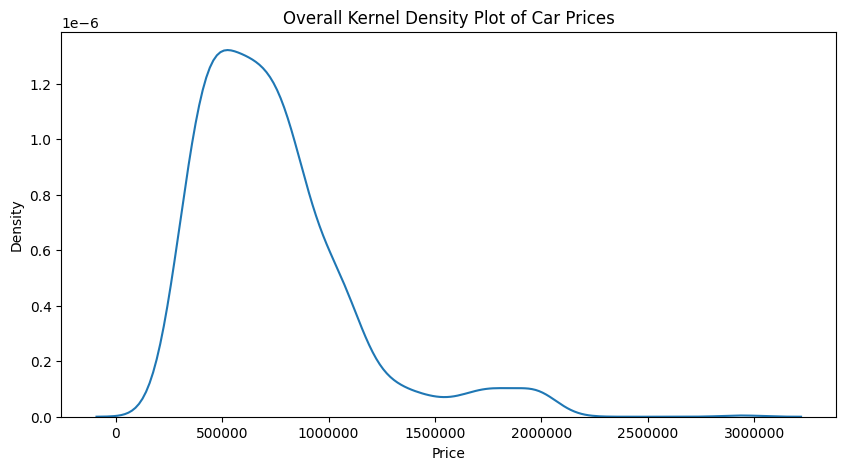

=== Price Summary by Body_Type ===
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


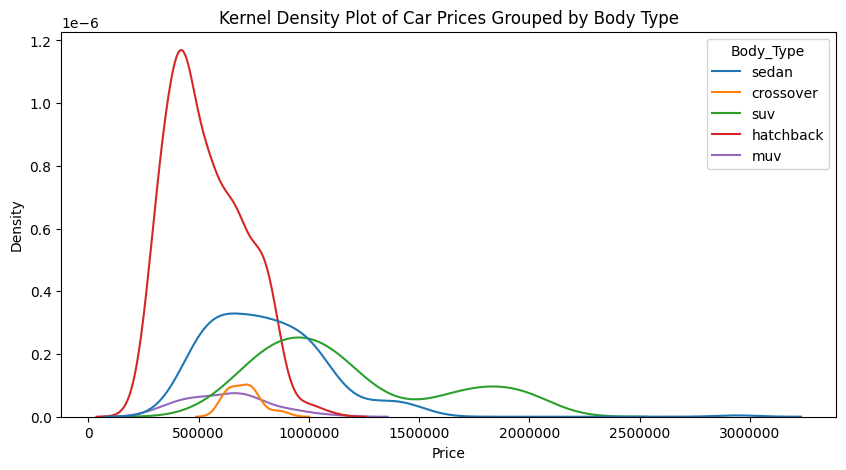

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cars = pd.read_csv('./data/cars_hw.csv')

print("=== Overall Price Summary ===")
print(cars['Price'].describe())
print("\n")

plt.figure(figsize=(10, 5))
sns.kdeplot(data=cars, x='Price')
plt.title('Overall Kernel Density Plot of Car Prices')
plt.ticklabel_format(style='plain', axis='x') 
plt.show()

print("=== Price Summary by Body_Type ===")
summary_by_body = cars.groupby('Body_Type')['Price'].describe()
print(summary_by_body)

plt.figure(figsize=(10, 5))
sns.kdeplot(data=cars, x='Price', hue='Body_Type')
plt.title('Kernel Density Plot of Car Prices Grouped by Body Type')
plt.ticklabel_format(style='plain', axis='x')
plt.show()


Based on the group means, SUVs are the most expensive car type on average (with a mean price of about 1.17 million). In addition, SUVs also have the highest standard deviation (about 0.69 million), indicating the most variability in price within that category.



  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?

  


In [ ]:
import pandas as pd
import statsmodels.api as sm

print("=== Regression summary treating seats as a continuous variable ===")
X_cont = sm.add_constant(cars['Seating_Capacity'])
model_cont = sm.OLS(cars['Price'], X_cont, missing='drop').fit()
print(model_cont.summary())
print("\n")

print("=== Regression summary treating seats as a categorical variable ===")
cars_dummies = pd.get_dummies(cars, columns=['Seating_Capacity'], drop_first=True)
features_cat = [col for col in cars_dummies.columns if col.startswith('Seating_Capacity_')]

X_cat = sm.add_constant(cars_dummies[features_cat].astype(float))
model_cat = sm.OLS(cars['Price'], X_cat, missing='drop').fit()
print(model_cat.summary())


=== Regression summary treating seats as a continuous variable ===
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0245
Time:                        22:08:02   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

The slope coefficient is ~59,268. This means that when forced into a linear model, the average price of a car increases by about 59,268 Indian rupees for every additional seat it has. The categorical model shows the relationship is actually curved. The price premium skyrockets for a 6-seat car (by ~1.45M rupees), but then drops drastically for 7 and 8 seaters. The relationship is highly non-linear.

  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

cars = cars.dropna(subset=['Price', 'Make_Year']).copy()
cars['Age'] = 2026 - cars['Make_Year']

X = cars[['Age']]
y = cars['Price']

kf = KFold(n_splits=10, shuffle=True, random_state=42)
lr = LinearRegression()

print("=== 10-Fold CV RMSE by Polynomial Degree of Age ===")

best_degree = 1
min_rmse = float('inf')

for degree in range(1, 9):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    
    neg_mse = cross_val_score(lr, X_poly, y, cv=kf, scoring='neg_mean_squared_error')
    rmse = np.mean(np.sqrt(-neg_mse))
    
    print(f"Degree {degree}: ${round(rmse, 2)}")
    
    if rmse < min_rmse:
        min_rmse = rmse
        best_degree = degree

print(f"\n=> The optimal number of powers (lowest RMSE) is: {best_degree}")


=== 10-Fold CV RMSE by Polynomial Degree of Age ===
Degree 1: $310765.36
Degree 2: $310779.3
Degree 3: $309697.34
Degree 4: $308871.57
Degree 5: $307368.98
Degree 6: $307522.52
Degree 7: $306433.42
Degree 8: $306919.53

=> The optimal number of powers (lowest RMSE) is: 7



  
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


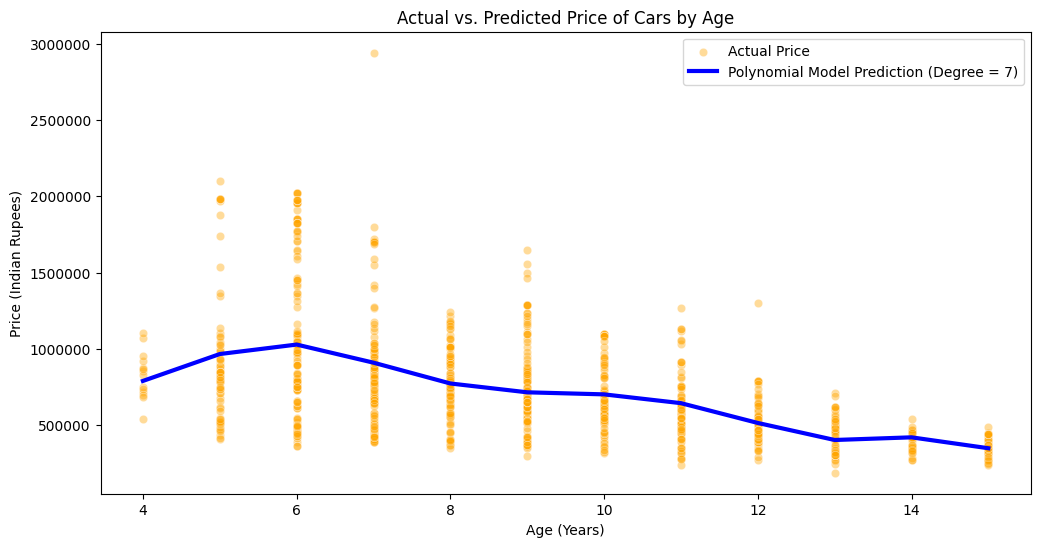

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

poly = PolynomialFeatures(degree=best_degree)
X_poly = poly.fit_transform(X)

final_model = lr.fit(X_poly, y)
cars['Predicted_Price'] = final_model.predict(X_poly)

plt.figure(figsize=(12, 6))

sns.scatterplot(data=cars, x='Age', y='Price', color='orange', alpha=0.4, label='Actual Price')

cars_sorted = cars.sort_values(by='Age')
plt.plot(cars_sorted['Age'], cars_sorted['Predicted_Price'], color='blue', linewidth=3, label=f'Polynomial Model Prediction (Degree = {best_degree})')

plt.title('Actual vs. Predicted Price of Cars by Age')
plt.xlabel('Age (Years)')
plt.ylabel('Price (Indian Rupees)')
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.show()


Yes. A polynomial regression captures the non-linear depreciation of cars (losing value rapidly when new, then the curve flattening out as they age), whereas a standard straight line would completely miss this trend. There may be slight upward at extreme older ages, which is a normal artifact of high-degree polynomials in areas with sparse data.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?


In [ ]:
import pandas as pd

heart = pd.read_csv('./data/heart_hw.csv')

survival_rates = heart.groupby('transplant')['y'].mean()
control_rate = survival_rates['control']
treatment_rate = survival_rates['treatment']
ate = treatment_rate - control_rate

print(f"(A) Control survival rate: {control_rate:.4f} ({control_rate*100:.2f}%)")
print(f"(B) Treatment survival rate: {treatment_rate:.4f} ({treatment_rate*100:.2f}%)")
print(f"Average Treatment Effect (ATE): {ate:.4f} ({ate*100:.2f}%)")


(A) Control survival rate: 0.1176 (11.76%)
(B) Treatment survival rate: 0.3478 (34.78%)
Average Treatment Effect (ATE): 0.2302 (23.02%)


The Average Treatment Effect (ATE) is 0.2302 or 23.02%. This means that receiving a heart transplant intervention increases the probability of surviving for three years by an absolute margin of 23.02% over the control group.




2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 



In [ ]:
import statsmodels.api as sm

heart_dummies = pd.get_dummies(heart, columns=['transplant'], drop_first=True)

X = heart_dummies[['transplant_treatment']].astype(float)
X = sm.add_constant(X)
y = heart_dummies['y']

model_heart = sm.OLS(y, X).fit()
print(model_heart.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0133
Time:                        22:26:22   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.1176 

The Intercept (0.1176) is exactly equal to the proportion of people who survive in the control group.

The Transplant Coefficient (0.2302) is exactly equal to the Average Treatment Effect (ATE) we calculated by subtracting the control survival rate from the treatment survival rate.


3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000357
Time:                        22:35:41   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.7020 

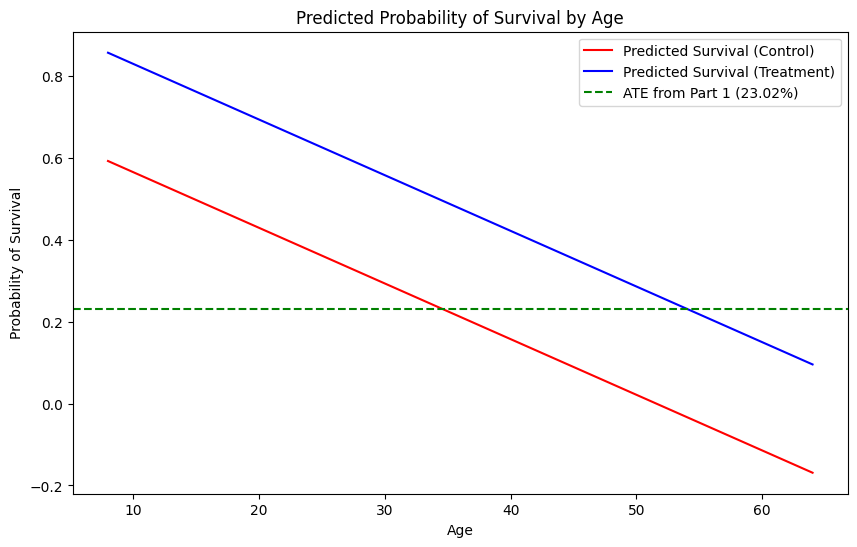

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare Features (Age and Transplant dummy variable)
heart_dummies = pd.get_dummies(heart, columns=['transplant'], drop_first=True)
X3 = heart_dummies[['transplant_treatment', 'age']].astype(float)
X3 = sm.add_constant(X3)
y = heart_dummies['y']

# 2. Fit Regression Model
model3 = sm.OLS(y, X3).fit()
print(model3.summary())

# 3. Create data for the plot
# We create a range of ages from the minimum age to maximum age in the dataset
age_range = np.linspace(heart['age'].min(), heart['age'].max(), 100)

# Calculate predicted lines using the coefficients from model3
intercept = model3.params['const']
transplant_coef = model3.params['transplant_treatment']
age_coef = model3.params['age']

# Control line equation: Intercept + Age_Coef * age
prob_control = intercept + (age_coef * age_range)
# Treatment line equation: Intercept + Transplant_Coef + Age_Coef * age
prob_treatment = intercept + transplant_coef + (age_coef * age_range)

# 4. Draw the Plot
plt.figure(figsize=(10, 6))
plt.plot(age_range, prob_control, color='red', label='Predicted Survival (Control)')
plt.plot(age_range, prob_treatment, color='blue', label='Predicted Survival (Treatment)')

# We plot the ATE (0.2302) as a horizontal dashed line as requested
plt.axhline(y=0.2302, color='green', linestyle='--', label='ATE from Part 1 (23.02%)')

plt.title('Predicted Probability of Survival by Age')
plt.xlabel('Age')
plt.ylabel('Probability of Survival')
plt.legend()
plt.show()


Because this specific model does not include an interaction between age and transplant, the new model assumes the impact of the transplant is exactly 26.47% for all ages. Therefore, the original naive ATE (23.02%) is actively under-estimating the impact of the transplant for every single age group.




4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000310
Time:                        22:37:33   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.3549 

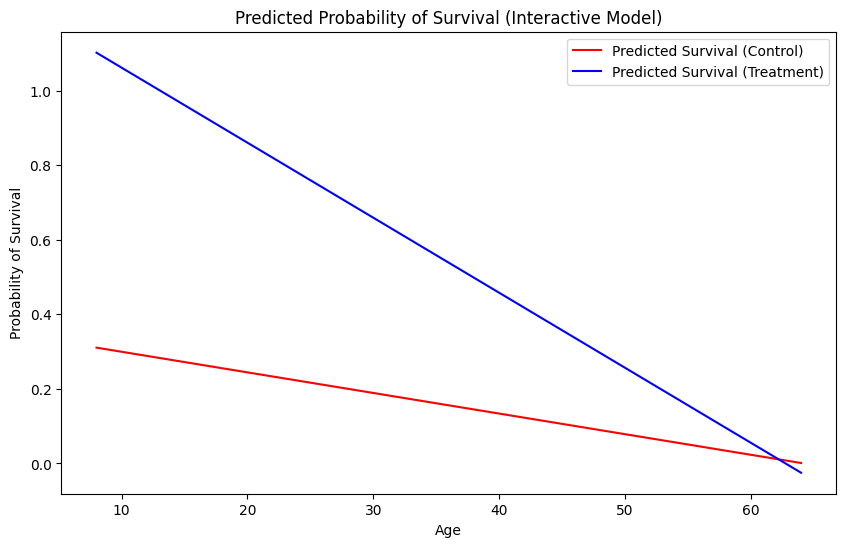

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

heart_dummies = pd.get_dummies(heart, columns=['transplant'], drop_first=True)
X4 = heart_dummies[['transplant_treatment', 'age']].astype(float)

X4['transplant_x_age'] = X4['transplant_treatment'] * X4['age']
X4 = sm.add_constant(X4)
y = heart_dummies['y']

model4 = sm.OLS(y, X4).fit()
print(model4.summary())

age_range = np.linspace(heart['age'].min(), heart['age'].max(), 100)

intercept = model4.params['const']
transplant_coef = model4.params['transplant_treatment']
age_coef = model4.params['age']
interaction_coef = model4.params['transplant_x_age']

prob_control_int = intercept + (age_coef * age_range)
prob_treatment_int = intercept + transplant_coef + (age_coef * age_range) + (interaction_coef * age_range)
plt.figure(figsize=(10, 6))
plt.plot(age_range, prob_control_int, color='red', label='Predicted Survival (Control)')
plt.plot(age_range, prob_treatment_int, color='blue', label='Predicted Survival (Treatment)')

plt.title('Predicted Probability of Survival (Interactive Model)')
plt.xlabel('Age')
plt.ylabel('Probability of Survival')
plt.legend()
plt.show()


It prevents the model from assuming the transplant helps everyone equally. By adding the interaction term, the survival prediction lines are no longer perfectly parallel—they now have different slopes. 

The interaction term (transplant_x_age) has a strongly negative coefficient. This pattern reveals that the transplant is massively beneficial for younger patients, but that survival benefit rapidly deteriorates as the patient's age increases. Eventually, the two lines actually intersect (around age 62), indicating that for elderly patients, undergoing the major surgery of a transplant may actually be more deadly than the control approach.




5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 



In [7]:
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

heart = pd.read_csv('./data/heart_hw.csv')

heart_clean = heart.dropna(subset=['y', 'transplant', 'age']).copy()
heart_dummies_cv = pd.get_dummies(heart_clean, columns=['transplant'], drop_first=True)
y_cv = heart_dummies_cv['y']

X2_cv = heart_dummies_cv[['transplant_treatment']]
X3_cv = heart_dummies_cv[['transplant_treatment', 'age']]
X4_cv = X3_cv.copy()
X4_cv['transplant_x_age'] = X4_cv['transplant_treatment'] * X4_cv['age']
kf = KFold(n_splits=10, shuffle=True, random_state=42)
lr = LinearRegression()

def get_rmse(X, y):
    neg_mse = cross_val_score(lr, X, y, cv=kf, scoring='neg_mean_squared_error')
    return np.mean(np.sqrt(-neg_mse))

print("==== 10-Fold Cross Validation Results (RMSE) ====")
print(f"Model 2 (Transplant Only): {get_rmse(X2_cv, y_cv):.4f}")
print(f"Model 3 (Transplant + Age): {get_rmse(X3_cv, y_cv):.4f}")
print(f"Model 4 (Interactive):     {get_rmse(X4_cv, y_cv):.4f}")



==== 10-Fold Cross Validation Results (RMSE) ====
Model 2 (Transplant Only): 0.4365
Model 3 (Transplant + Age): 0.4167
Model 4 (Interactive):     0.4130



6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

The model makes life-or-death decisions using only age. It completely ignores vital medical context such as the severity of the patient's illness, compatibility, immune system health, and wait times. Basing priority strictly on age structurally discriminates against older patients (ageism) regardless of their individual medical circumstances.


The target variable y is binary 0 for death, 1 for survival, but we used Linear Regression (OLS). As discussed in Question 1, linear regression outputs are not bounded between 0 and 1, meaning the model can output impossible probabilities (like predicting a patient has a -15% chance to survive. Relying on mathematically broken scores for medical priority is dangerous so we should be using Logistic Regression instead.